In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize
import scipy.stats as scst
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from sklearn.mixture import GaussianMixture
import random
import scipy.stats as stats
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from matplotlib import cm
from matplotlib.colors import Normalize
import statsmodels.api as sm

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

# Extracts position of the CDR in centromeres

This is based on the data from Gao et al., 2026, Nature, A global view of human centromere variation and evolution

I downloaded the data bundle from `https://doi.org/10.6084/m9.figshare.29921990`

In [4]:
chromosomes = [f"chr{i}" for i in range(1, 23)]

### load cdr location and hor annoations

In [5]:
cdr_df = pd.read_csv(
    "/home/hain/EMBL/Centromere_project/revision/data/29921990/Centromere sequences annotation of HGSVC3, CHM1 and CHM13/centromere dip region annotation.bed",
    sep="\t",
    header=None,
    names=["cent_cutout", "cdr_start", "cdr_end"]
)
cdr_df["cdr_mean"] = (cdr_df["cdr_start"] + cdr_df["cdr_end"]) / 2
cdr_df.head()

,cent_cutout,cdr_start,cdr_end,cdr_mean
0,chm13_chr10:38568472-42561808,39993472,40058470,40025971.0
1,chm13_chr10:38568472-42561808,40058472,40123472,40090972.0
2,chm13_chr10:38568472-42561808,40123474,40178472,40150973.0
3,chm13_chr1:121119216-127324115,122674216,122759214,122716715.0
4,chm13_chr1:121119216-127324115,122759216,122794216,122776716.0


In [6]:
### add chromosome column
col_chrom = []
for idx, row in cdr_df.iterrows():
    cent_cutout = row["cent_cutout"]
    chrom = "NA"
    for s1 in row["cent_cutout"].split("_"):
        for s2 in s1.split(":"):
            if s2.startswith("chr"):
                chrom = s2
                break
    col_chrom.append(chrom)

cdr_df["chrom"] = col_chrom

In [7]:
hor_df_chrom = []
for chrom in tqdm(chromosomes, total=len(chromosomes), desc="Loading HOR annotation files"):
    hor_df_chrom.append(
        pd.read_csv(
            f"/home/hain/EMBL/Centromere_project/revision/data/29921990/Centromere sequences annotation of HGSVC3, CHM1 and CHM13/alpha satellite higher order repeat annotation/{chrom}_AS-HOR_stv_row.all.bed",
            sep="\t",
            header=None,
            names=["cent_cutout", "hor_start", "hor_end", "hor_name", "score", "strand", "tstart", "tend", "color"]
        )
    )
hor_df = pd.concat(hor_df_chrom, ignore_index=True).reset_index(drop=True).sort_values(by=["cent_cutout", "hor_start"]).reset_index(drop=True)
hor_df["hor_length"] = hor_df["hor_end"] - hor_df["hor_start"]
hor_df

Loading HOR annotation files: 100%|██████████| 22/22 [00:07<00:00,  3.13it/s]


,cent_cutout,hor_start,hor_end,hor_name,score,strand,tstart,tend,color,hor_length
0,HG00096_chr10_haplotype2-0000118:38552782-4215...,39589884,39590223,S1C10H1L.2_7/5,0,+,39589884,39590223,"0,0,0",339
1,HG00096_chr10_haplotype2-0000118:38552782-4215...,39590224,39590563,S1C10H1L.2_5,0,+,39590224,39590563,"0,0,0",339
2,HG00096_chr10_haplotype2-0000118:38552782-4215...,39590564,39590903,S1C10H1L.2_5,0,+,39590564,39590903,"0,0,0",339
3,HG00096_chr10_haplotype2-0000118:38552782-4215...,39590904,39591243,S1C10H1L.2_5,0,+,39590904,39591243,"0,0,0",339
4,HG00096_chr10_haplotype2-0000118:38552782-4215...,39591244,39591583,S1C10H1L.2_5,0,+,39591244,39591583,"0,0,0",339
...,...,...,...,...,...,...,...,...,...,...
6503199,chm1_chr9:44537770-48088919,47578865,47580054,S2C9H1L.1-7,0,+,47578865,47580054,"0,0,0",1189
6503200,chm1_chr9:44537770-48088919,47580055,47580904,S2C9H1L.1-4_5/1,0,+,47580055,47580904,"0,0,0",849
6503201,chm1_chr9:44537770-48088919,47582948,47583118,S2C9H1L.7,0,+,47582948,47583118,"0,0,0",170
6503202,chm1_chr9:44537770-48088919,47583119,47583456,S2C9H1L.1-2,0,+,47583119,47583456,"0,0,0",337


In [8]:
### get relative position of the CDR
"""
For this I want to iterate over each individual haplotype and calculate the relative position of its CDR(s). For this I will 
    - (b) query them from left to right,
    - (c) check after how many HOR bases I find the repeat unit that contains the CDR (just use the start position)
    - (d) calculate the relative CDR position based on the queried bases until the CDR position divided by the total number of HOR bases
"""

rel_cdr_data = []

for hp, hp_hor_df in tqdm(hor_df[hor_df["hor_name"].str.contains("L.")].groupby("cent_cutout"), total=hor_df["cent_cutout"].nunique(), desc="Processing haplotypes"):

    # find CDR(s) for this hp
    cdr_positions = cdr_df[cdr_df["cent_cutout"] == hp]["cdr_mean"].tolist()
    # find chromosome for this hp
    chrom = cdr_df[cdr_df["cent_cutout"] == hp]["chrom"].tolist()[0]

    # iterate over the CDRs
    for cdr_pos in cdr_positions:
        # prepare number of HOR bases
        total_hor_bases = hp_hor_df["hor_length"].sum()
        queried_hor_bases = 0
        # iterate over the HORs for this hp
        for idx, row in hp_hor_df.iterrows():
            queried_hor_bases += row["hor_length"]
            if cdr_pos <= row["hor_start"]:
                # found the HOR that contains the CDR
                break
        rel_cdr_data.append({"chromosome":chrom, "cent_cutout":hp, "cdr_mean":cdr_pos, "rel_cdr_position":queried_hor_bases / total_hor_bases})
            
rel_cdr_df = pd.DataFrame(rel_cdr_data)

Processing haplotypes: 100%|██████████| 2058/2058 [02:50<00:00, 12.08it/s]


### add cluster information

In [9]:
### add sample and haplotype columns
col_hp = []
col_sample = []
for idx, row in rel_cdr_df.iterrows():
    cent_cutout = row["cent_cutout"]
    sample = cent_cutout.split("_")[0]
    if "haplotype1" in cent_cutout:
        hp = "HP1"
    elif "haplotype2" in cent_cutout:
        hp = "HP2"
    else:
        hp = "NA"
    col_hp.append(hp)
    col_sample.append(sample)
rel_cdr_df["haplotype"] = col_hp
rel_cdr_df["sample"] = col_sample

In [10]:
samplesheet = pd.read_csv("/home/hain/EMBL/Centromere_project/samplesheet/centromeres_full.active.length.cluster.tsv", sep="\t")
samplesheet.head()

,SAMPLE,ASM,HP,PROJECT,CHROM,CENT_FASTA_PATH,NUM_CONTIGS,CONTIG_LENGTH,FAMILY,FAMILYSTATE,SUPERPOP,POP,ID,ACTIVE,UNSTABLE,HOR_LENGTH,HOR_SPAN,ARCHITECTURE
0,CHM1,T2T,HP1,T2T,chr21,/scratch/hain/centromere/centromeres/chr21_CHM...,1,1819674,NaN,NaN,EAS,NaN,CHM1_HP1_T2T_T2T,True,False,1176502,1228355,chr21_968
1,HG04204,HPRC,HP2,HPRC2,chr3,/scratch/hain/centromere/centromeres/chr3_HG04...,1,5273549,ST006,child,SAS,STU,HG04204_HP2_HPRC_HPRC2,True,False,2140104,4006938,chr3_1009
2,HG03704,HPRC,HP2,HPRC2,chr2,/scratch/hain/centromere/centromeres/chr2_HG03...,1,4968267,PK60,child,SAS,PJL,HG03704_HP2_HPRC_HPRC2,True,False,2180995,2214651,chr2_929
3,HG00731,VERKKO,HP2,HGSVC,chr20,/scratch/hain/centromere/centromeres/chr20_HG0...,1,7316426,PR05,father,AMR,PUR,HG00731_HP2_VERKKO_HGSVC,True,False,2445974,5672092,chr20_1081
4,HG03369,HPRC,HP2,HPRC2,chr4,/scratch/hain/centromere/centromeres/chr4_HG03...,1,4918950,NG98,mother,AFR,ESN,HG03369_HP2_HPRC_HPRC2,True,False,3413929,3677878,chr4_1075


In [11]:
col_cluster = []

for idx, row in rel_cdr_df.iterrows():
    sample = row["sample"]
    cluster_df = samplesheet[
        (samplesheet["SAMPLE"] == sample) &
        (samplesheet["HP"] == row["haplotype"]) &
        (samplesheet["CHROM"] == row["chromosome"])
    ]["ARCHITECTURE"]
    if cluster_df.empty:
        cluster = "NA"
    else:
        cluster = cluster_df.tolist()[0]
    col_cluster.append(cluster)
rel_cdr_df["cluster"] = col_cluster

(0.0, 1.0)

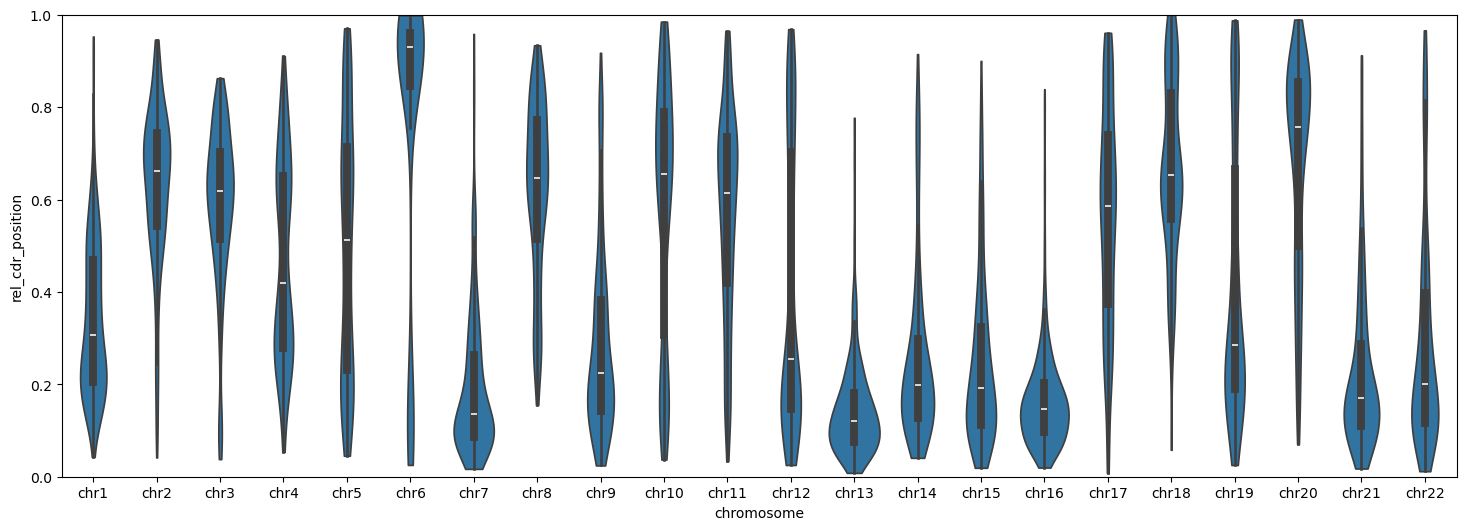

In [12]:
fig, ax = plt.subplots(figsize=(18, 6))
sns.violinplot(x="chromosome", y="rel_cdr_position", data=rel_cdr_df, order=chromosomes, ax=ax, cut=0)
ax.set_ylim(0, 1)

/tmp/ipykernel_12475/3823497253.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_12475/3823497253.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_12475/3823497253.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_12475/3823497253.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_12475/3823497253.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_12475

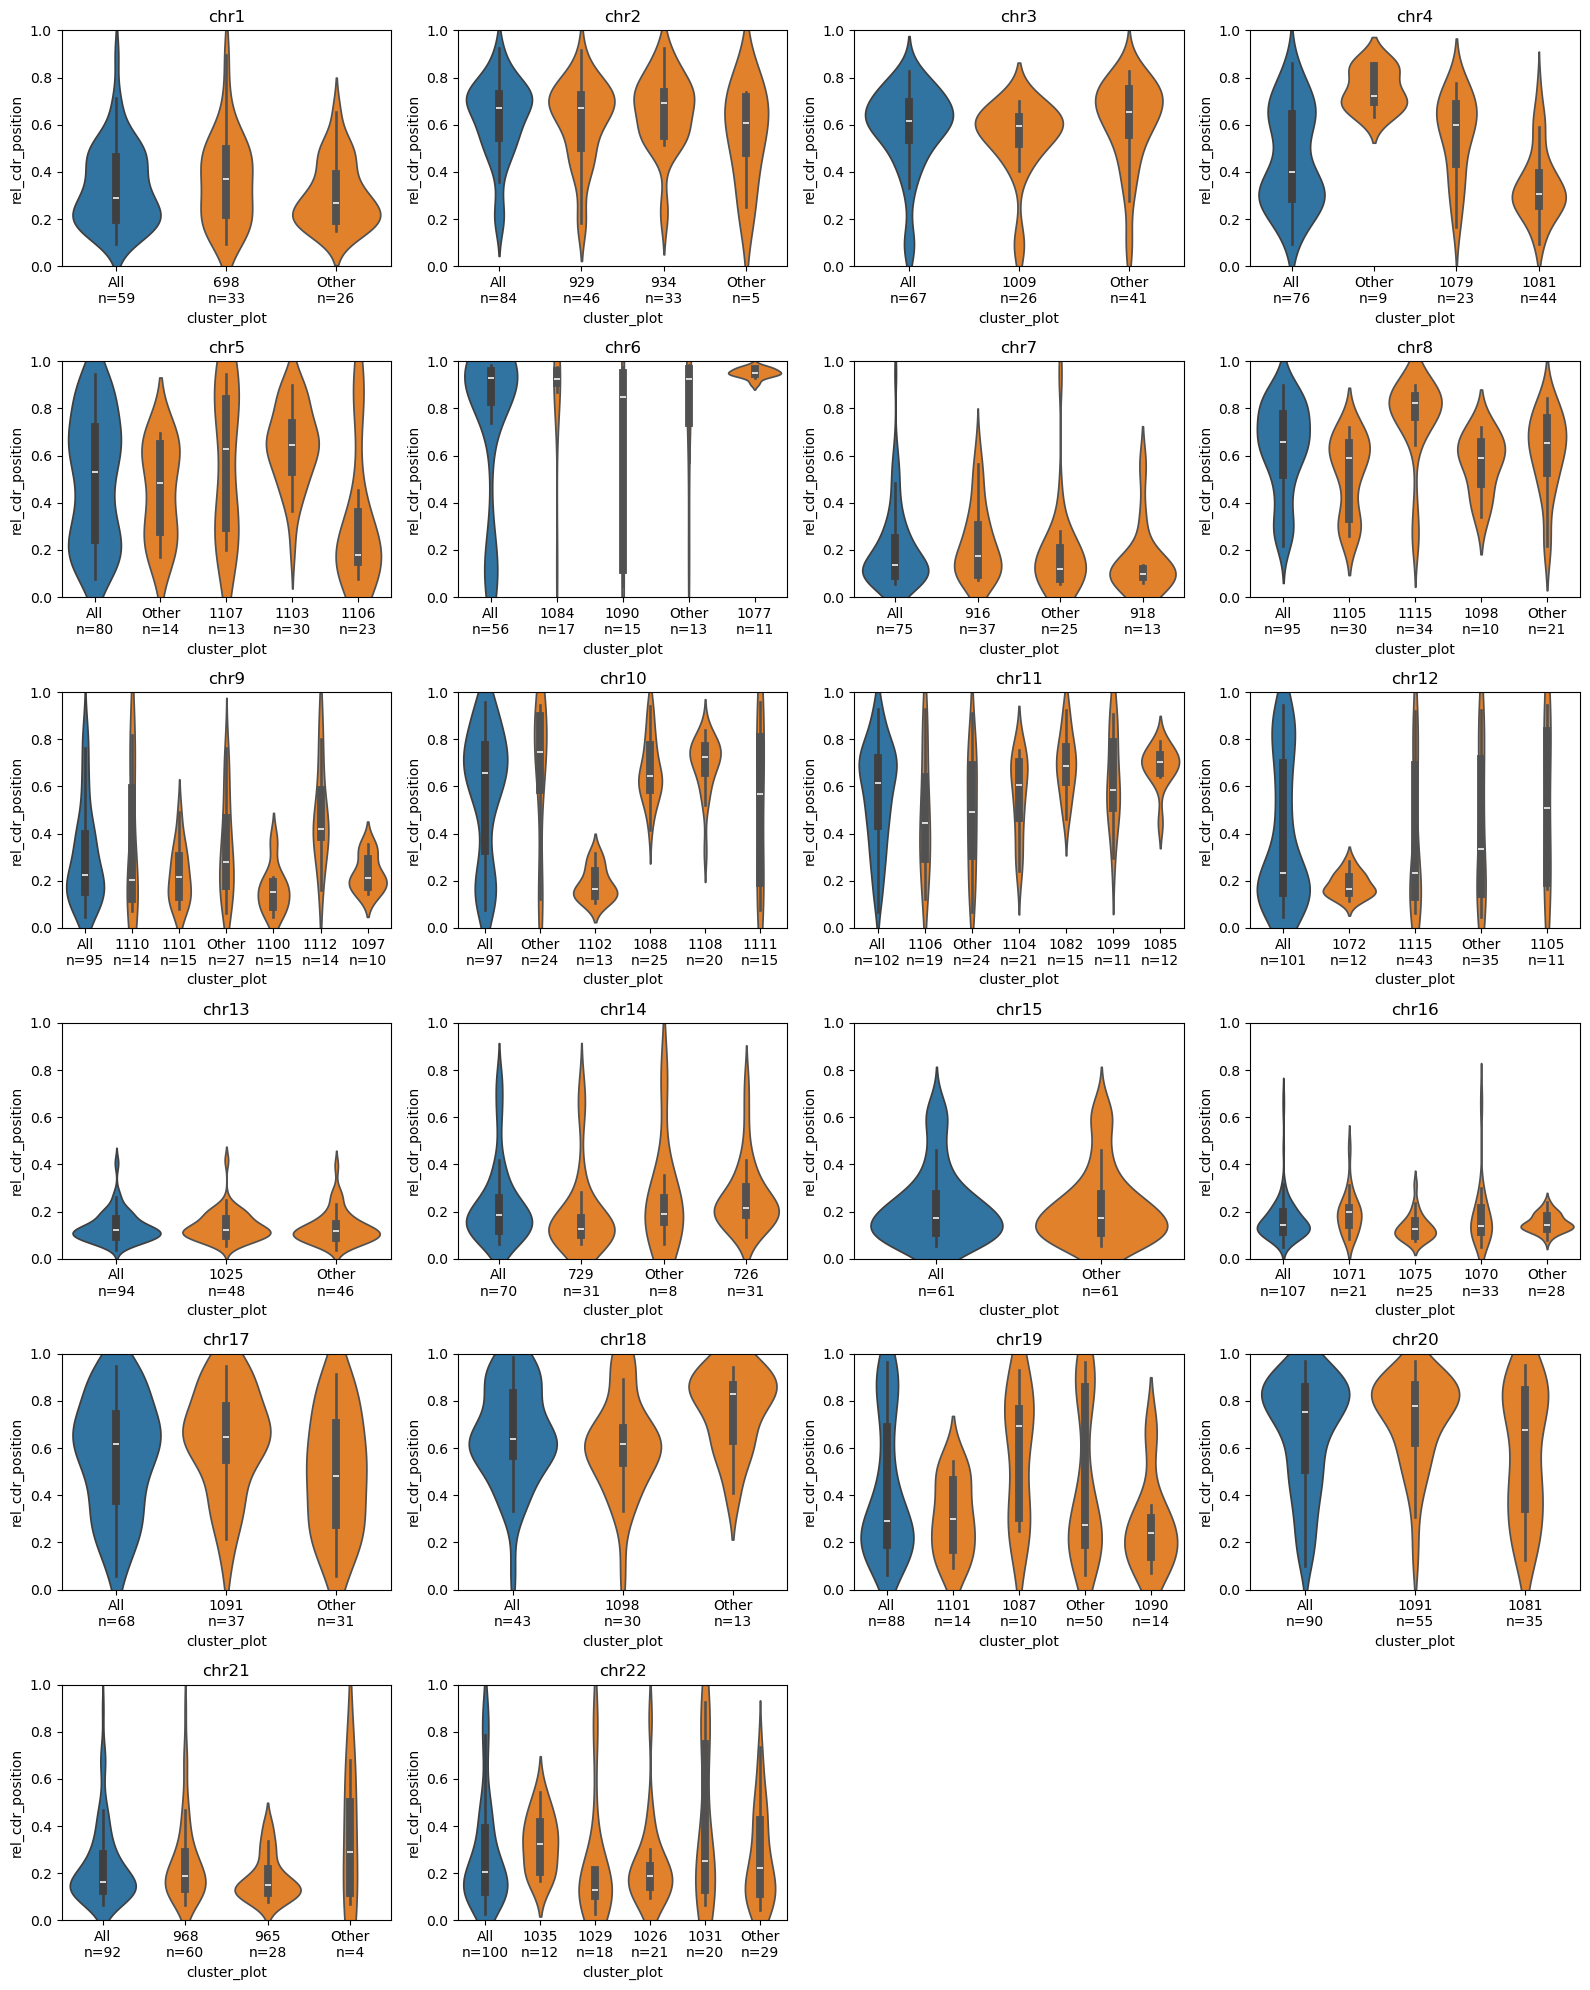

In [18]:
for k, chrom in enumerate(chromosomes):
    
    ### merge cdrs
    # collapse duplicated cent_cutout entries by averaging rel_cdr_position
    plot_df = (
        rel_cdr_df[(rel_cdr_df["chromosome"] == chrom) & (rel_cdr_df["cluster"] != "NA")]
        .groupby("cent_cutout", as_index=False)
        .agg(
            chromosome=("chromosome", "first"),
            haplotype=("haplotype", "first"),
            sample=("sample", "first"),
            cluster=("cluster", "first"),
            rel_cdr_position=("rel_cdr_position", "mean"),
            n_rows_merged=("rel_cdr_position", "size")
        )
    )

    col_updated_cluster = []
    for idx, row in plot_df.iterrows():
        if plot_df[plot_df["cluster"] == row["cluster"]].shape[0] < 10:
            col_updated_cluster.append("Other")
        else:
            col_updated_cluster.append(row["cluster"].split("_")[1] + "\nn=" + str(plot_df[plot_df["cluster"] == row["cluster"]].shape[0]))
    plot_df["cluster_plot"] = col_updated_cluster
    n_other = plot_df[plot_df["cluster_plot"] == "Other"].shape[0]
    plot_df["cluster_plot"] = plot_df["cluster_plot"].replace("Other", f"Other\nn={n_other}")
    
    ax = plt.subplot(6, 4, k + 1)
    ax.set_title(chrom)
    sns.violinplot(
        plot_df,
        y="rel_cdr_position",
        ax=ax
    )
    sns.violinplot(
        plot_df,
        x="cluster_plot",
        y="rel_cdr_position",
        ax=ax
    )
    
    labels = ax.get_xticklabels()
    labels[0] = f"All\nn={plot_df.shape[0]}"
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)

plt.gcf().set_size_inches(16, 20)
plt.tight_layout()
plt.show()
plt.close()

### Compare with old data

In [20]:
old_rel_cdr = pd.read_csv("/home/hain/mnt/korbel/hain/centromere/CDR_position_2026_05_08.tsv", sep="\t").set_index("chrom")

In [62]:
old_rel_cdr["old_median_rel_cdr"] = old_rel_cdr["norm_mean_dip_median"]

col_new_median_rel_cdr = []
col_new_low_rel_cdr = []
col_new_high_rel_cdr = []

for idx, row in old_rel_cdr.iterrows():
    chrom = row.name
    new_median_rel_cdr = rel_cdr_df[rel_cdr_df["chromosome"] == chrom]["rel_cdr_position"].median()
    new_low_rel_cdr = rel_cdr_df[rel_cdr_df["chromosome"] == chrom]["rel_cdr_position"].quantile(0.25)
    new_high_rel_cdr = rel_cdr_df[rel_cdr_df["chromosome"] == chrom]["rel_cdr_position"].quantile(0.75)
    col_new_low_rel_cdr.append(new_low_rel_cdr)
    col_new_high_rel_cdr.append(new_high_rel_cdr)
    col_new_median_rel_cdr.append(new_median_rel_cdr)
    
old_rel_cdr["new_median_rel_cdr"] = col_new_median_rel_cdr
old_rel_cdr["new_low_rel_cdr"] = col_new_low_rel_cdr
old_rel_cdr["new_high_rel_cdr"] = col_new_high_rel_cdr

In [63]:
old_rel_cdr

,norm_mean_dip_median,old_median_rel_cdr,new_median_rel_cdr,diff,new_low_rel_cdr,new_high_rel_cdr
chrom,,,,,,
chr13,0.104980,0.104980,0.120941,0.015961,0.075978,0.181922
chr16,0.130457,0.130457,0.146457,0.016001,0.096021,0.203329
chr21,0.137299,0.137299,0.171184,0.033886,0.110617,0.288258
chr7,0.139012,0.139012,0.135914,0.003098,0.086272,0.263464
chr14,0.163277,0.163277,0.198463,0.035186,0.126702,0.298007
chr15,0.165987,0.165987,0.191761,0.025774,0.111620,0.323446
chr22,0.187165,0.187165,0.200283,0.013117,0.115726,0.397269
chr9,0.239673,0.239673,0.224281,0.015392,0.143246,0.382996
chr12,0.275072,0.275072,0.254269,0.020803,0.145880,0.702083


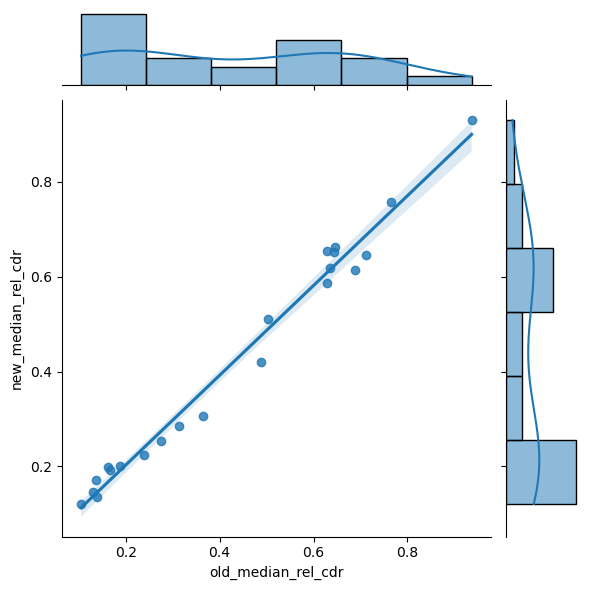

In [24]:
sns.jointplot(
    data=old_rel_cdr,
    x="old_median_rel_cdr",
    y="new_median_rel_cdr",
    kind="reg"
)

In [32]:
import numpy as np

In [65]:
old_rel_cdr["diff"] = np.abs(old_rel_cdr["new_median_rel_cdr"] - old_rel_cdr["old_median_rel_cdr"])

In [67]:
df_gmm = pd.read_csv("/home/hain/EMBL/Centromere_project/revision/data/__ARM_LOSS_PCAWG_GMM_STRONG_TRUNC_DATA.tsv", sep="\t")

col_chrom = []
col_arm = []
col_old_cdr = []
col_new_cdr = []
col_new_cdr_low = []
col_new_cdr_high = []

for idx, row in df_gmm.iterrows():
    chrom = row["EVENT"].split("_")[0]
    arm = row["EVENT"].split("_")[1]

    col_chrom.append(chrom)
    col_arm.append(arm)
    col_old_cdr.append(old_rel_cdr.loc[chrom, "old_median_rel_cdr"])
    col_new_cdr.append(old_rel_cdr.loc[chrom, "new_median_rel_cdr"])
    col_new_cdr_low.append(old_rel_cdr.loc[chrom, "new_low_rel_cdr"])
    col_new_cdr_high.append(old_rel_cdr.loc[chrom, "new_high_rel_cdr"])
    
df_gmm["chrom"] = col_chrom
df_gmm["old_cdr"] = col_old_cdr
df_gmm["new_cdr"] = col_new_cdr
df_gmm["new_cdr_low"] = col_new_cdr_low
df_gmm["new_cdr_high"] = col_new_cdr_high
df_gmm["arm"] = col_arm

df_gmm

,EVENT,N,STRONG_TRUNC,chrom,old_cdr,new_cdr,new_cdr_low,new_cdr_high,arm
0,chr1_P,22,2.091661e-01,chr1,0.364205,0.306536,0.204897,0.468873,P
1,chr3_P,47,3.201732e-01,chr3,0.635414,0.617397,0.513998,0.702672,P
2,chr4_P,14,3.500127e-01,chr4,0.488969,0.420245,0.279430,0.651297,P
3,chr4_Q,12,5.307848e-02,chr4,0.488969,0.420245,0.279430,0.651297,Q
4,chr5_Q,25,8.593574e-02,chr5,0.502761,0.511932,0.231301,0.713229,Q
5,chr6_Q,12,5.217045e-17,chr6,0.936569,0.930318,0.844695,0.960986,Q
6,chr8_P,25,2.669456e-01,chr8,0.710880,0.646674,0.514072,0.772600,P
7,chr9_P,17,2.175603e-01,chr9,0.239673,0.224281,0.143246,0.382996,P
8,chr9_Q,6,3.378323e-01,chr9,0.239673,0.224281,0.143246,0.382996,Q
9,chr10_P,11,3.824034e-01,chr10,0.629617,0.654622,0.307074,0.789359,P


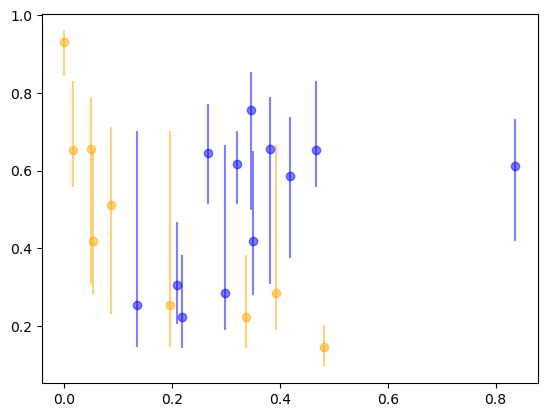

In [68]:
fig, ax = plt.subplots()

for idx, row in df_gmm.iterrows():
    ax.errorbar(
        x=row["STRONG_TRUNC"],
        y=row["new_cdr"],
        yerr=[[row["new_cdr"] - row["new_cdr_low"]], [row["new_cdr_high"] - row["new_cdr"]]],
        fmt="o",
        color="blue" if row["arm"] == "P" else "orange",
        alpha=0.5
    )

In [55]:
df_gmm[(df_gmm["N"] >= 10) & (df_gmm["arm"] == "P")]

,EVENT,N,STRONG_TRUNC,chrom,old_cdr,new_cdr,arm
0,chr1_P,22,0.209166,chr1,0.364205,0.306536,P
1,chr3_P,47,0.320173,chr3,0.635414,0.617397,P
2,chr4_P,14,0.350013,chr4,0.488969,0.420245,P
6,chr8_P,25,0.266946,chr8,0.710880,0.646674,P
7,chr9_P,17,0.217560,chr9,0.239673,0.224281,P
9,chr10_P,11,0.382403,chr10,0.629617,0.654622,P
12,chr12_P,19,0.134378,chr12,0.275072,0.254269,P
15,chr17_P,102,0.417968,chr17,0.629050,0.585793,P
18,chr19_P,13,0.297497,chr19,0.313587,0.285760,P
20,chr20_P,21,0.346307,chr20,0.766003,0.756932,P


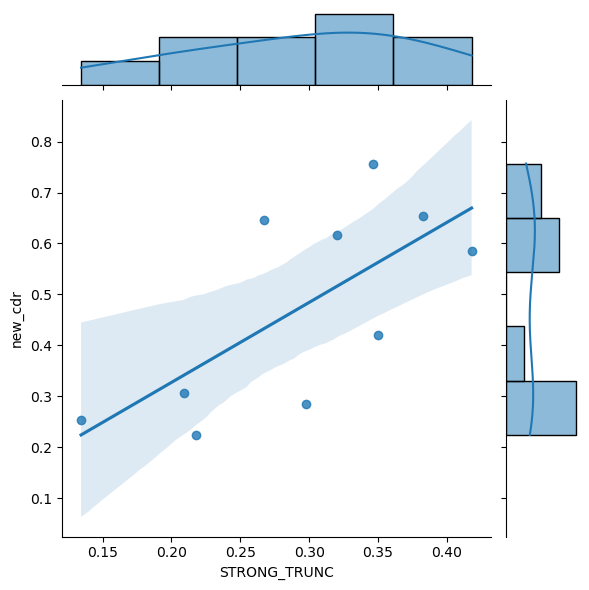

In [56]:
sns.jointplot(
    data=df_gmm[(df_gmm["N"] >= 10) & (df_gmm["arm"] == "P")],
    x="STRONG_TRUNC",
    y="new_cdr",
    kind="reg"
)

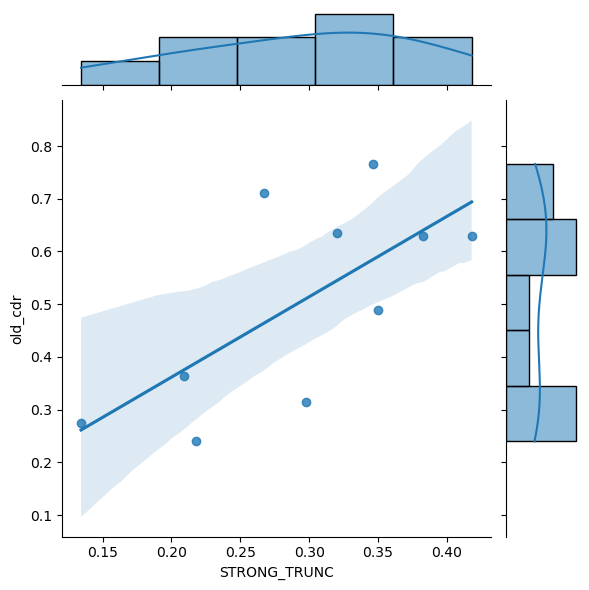

In [57]:
sns.jointplot(
    data=df_gmm[(df_gmm["N"] >= 10) & (df_gmm["arm"] == "P")],
    x="STRONG_TRUNC",
    y="old_cdr",
    kind="reg"
)

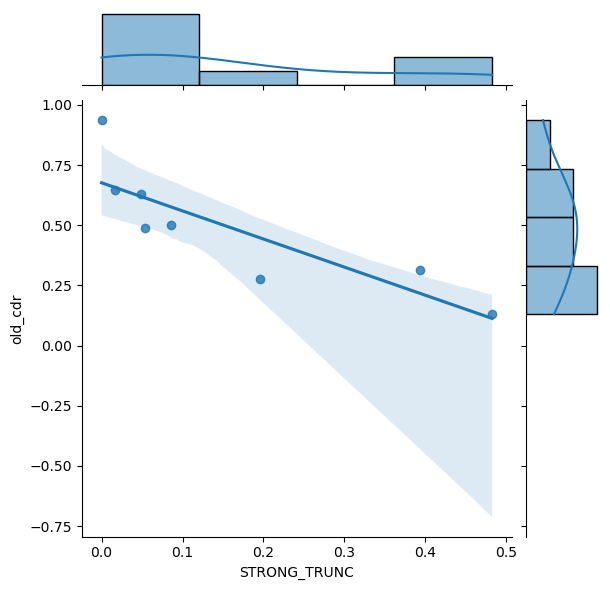

In [61]:
sns.jointplot(
    data=df_gmm[(df_gmm["N"] >= 10) & (df_gmm["arm"] == "Q")],
    x="STRONG_TRUNC",
    y="old_cdr",
    kind="reg"
)

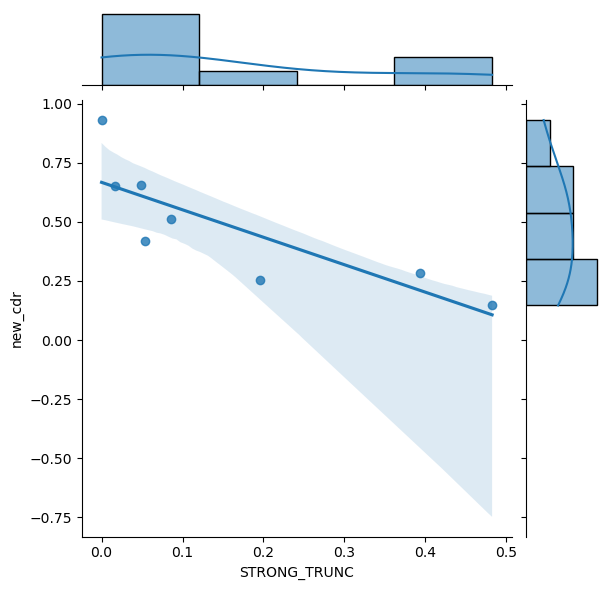

In [59]:
sns.jointplot(
    data=df_gmm[(df_gmm["N"] >= 10) & (df_gmm["arm"] == "Q")],
    x="STRONG_TRUNC",
    y="new_cdr",
    kind="reg"
)

In [49]:
import statsmodels.api as sm

In [58]:
for arm in ["P", "Q"]:
    for data_source in ["old_cdr", "new_cdr"]:
        df = df_gmm[(df_gmm["N"] >= 10) & (df_gmm["arm"] == arm)]
        
        x = df["STRONG_TRUNC"].tolist()
        y = df[data_source].tolist()
        
        x_c = sm.add_constant(x)
        model = sm.OLS(y, x_c).fit()
        print(f"Arm: {arm}, Data source: {data_source}")
        print(model.summary())

Arm: P, Data source: old_cdr
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.474
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     7.220
Date:                Wed, 26 Aug 2026   Prob (F-statistic):             0.0276
Time:                        16:38:02   Log-Likelihood:                 5.9567
No. Observations:                  10   AIC:                            -7.913
Df Residuals:                       8   BIC:                            -7.308
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0565  

/home/hain/miniconda3/envs/jupyter_wave/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  k, _ = kurtosistest(a, axis)
/home/hain/miniconda3/envs/jupyter_wave/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  k, _ = kurtosistest(a, axis)
/home/hain/miniconda3/envs/jupyter_wave/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  k, _ = kurtosistest(a, axis)
/home/hain/miniconda3/envs/jupyter_wave/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  k, _ = kurtosistest(a, axis)


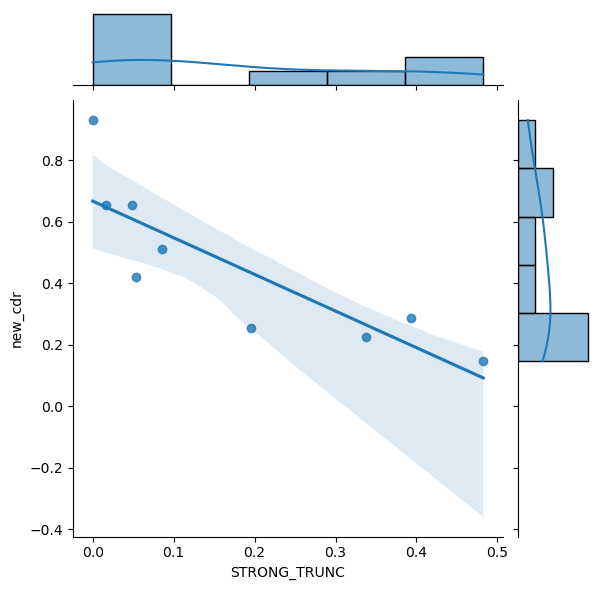

In [47]:
sns.jointplot(
    data=df_gmm[df_gmm["arm"] == "Q"],
    x="STRONG_TRUNC",
    y="new_cdr",
    kind="reg"
)